In [19]:
df.to_csv('startup_financial_data.csv', index=False)
print("CSV saved successfully!")

CSV saved successfully!


In [20]:
# Executive Summary
print("=" * 50)
print("STARTUP FINANCIAL ANALYSIS - EXECUTIVE SUMMARY")
print("=" * 50)

print("\n📊 Total Revenue by Startup:")
print(df.groupby('Startup')['Revenue'].sum().apply(lambda x: f'€{x:,.0f}'))

print("\n🔥 Average Burn Rate:")
print(df.groupby('Startup')['Burn_Rate'].mean().apply(lambda x: f'€{x:,.0f}'))

print("\n💡 Average LTV/CAC Ratio:")
print(df.groupby('Startup')['LTV_CAC_Ratio'].mean().apply(lambda x: f'{x:.2f}x'))

print("\n✅ Best Performer:", df.groupby('Startup')['Revenue'].sum().idxmax())
print("⚠️  Highest Burn:", df.groupby('Startup')['Burn_Rate'].mean().idxmax())

STARTUP FINANCIAL ANALYSIS - EXECUTIVE SUMMARY

📊 Total Revenue by Startup:
Startup
AlphaTech      €6,047,216
BetaFlow       €7,004,491
DeltaHealth    €6,917,625
EpsilonFin     €9,121,224
GammaAI        €8,575,057
Name: Revenue, dtype: str

🔥 Average Burn Rate:
Startup
AlphaTech      €369,491
BetaFlow       €222,783
DeltaHealth    €350,688
EpsilonFin     €522,426
GammaAI        €301,922
Name: Burn_Rate, dtype: str

💡 Average LTV/CAC Ratio:
Startup
AlphaTech      3.08x
BetaFlow       3.56x
DeltaHealth    4.03x
EpsilonFin     3.71x
GammaAI        3.52x
Name: LTV_CAC_Ratio, dtype: str

✅ Best Performer: EpsilonFin
⚠️  Highest Burn: EpsilonFin


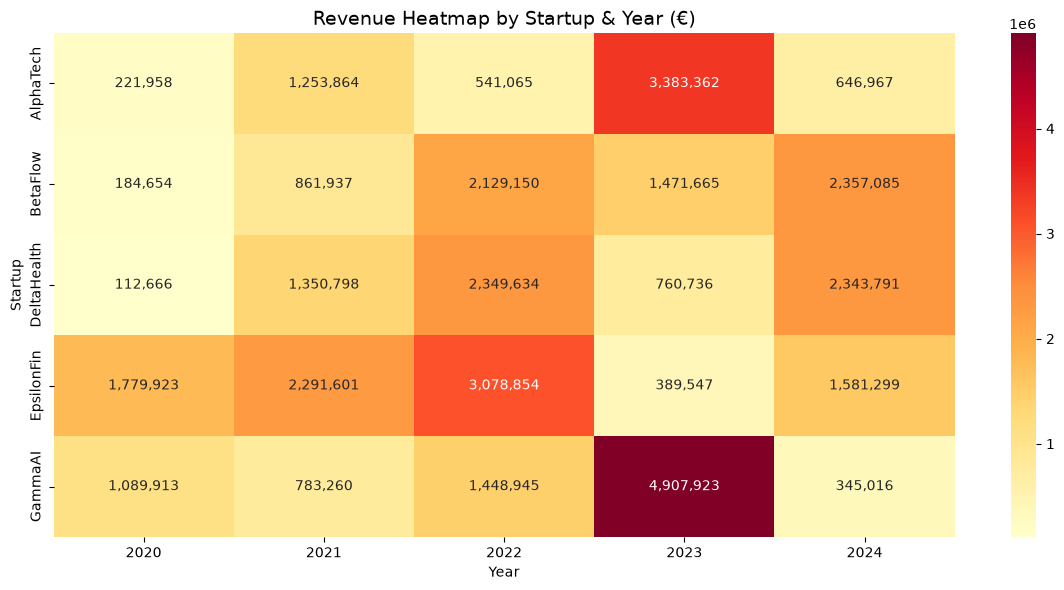

In [21]:
# Financial Summary Heatmap
pivot_revenue = df.pivot_table(values='Revenue', index='Startup', columns='Year', aggfunc='sum')

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(pivot_revenue, annot=True, fmt=',.0f', cmap='YlOrRd', ax=ax)

ax.set_title('Revenue Heatmap by Startup & Year (€)', fontsize=14)
plt.tight_layout()
plt.show()

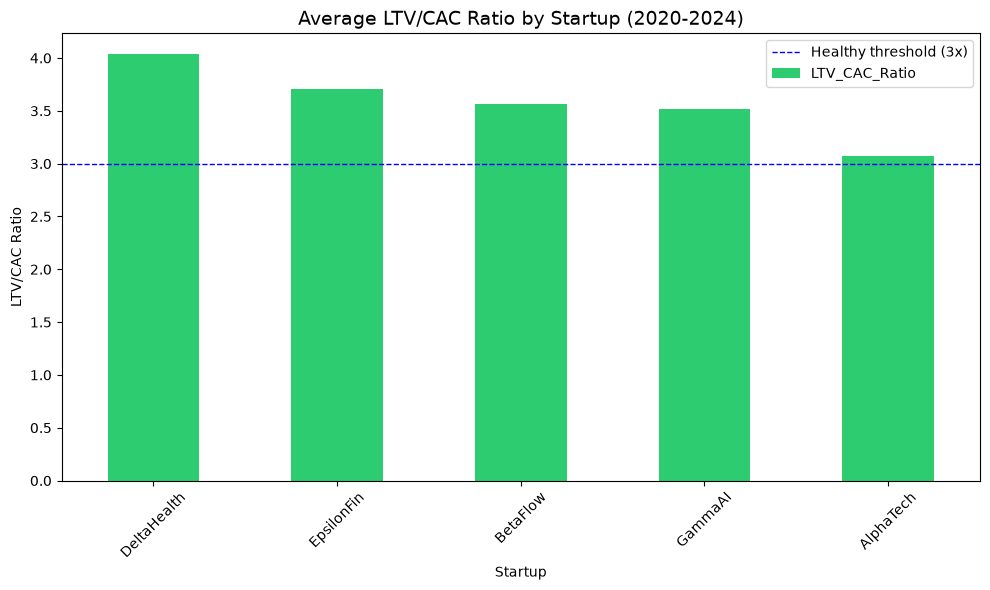

In [22]:
# LTV/CAC Ratio by Startup
ltv_cac_avg = df.groupby('Startup')['LTV_CAC_Ratio'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2ecc71' if x >= 3 else '#e74c3c' for x in ltv_cac_avg]
ltv_cac_avg.plot(kind='bar', ax=ax, color=colors)

ax.set_title('Average LTV/CAC Ratio by Startup (2020-2024)', fontsize=14)
ax.set_xlabel('Startup')
ax.set_ylabel('LTV/CAC Ratio')
ax.axhline(y=3, color='blue', linestyle='--', linewidth=1, label='Healthy threshold (3x)')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

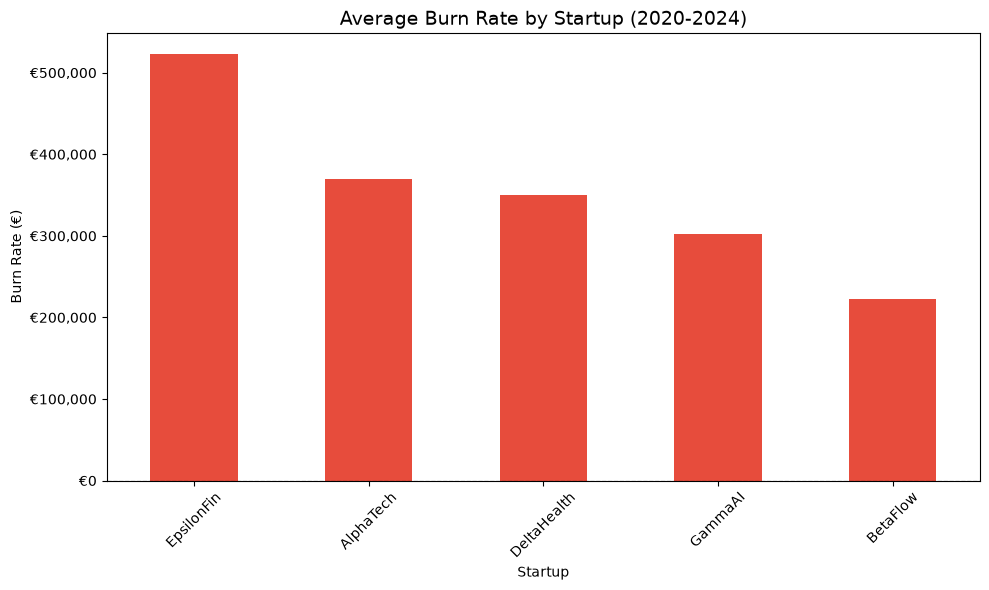

In [23]:
# Average Burn Rate by Startup
burn_avg = df.groupby('Startup')['Burn_Rate'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if x > 0 else '#2ecc71' for x in burn_avg]
burn_avg.plot(kind='bar', ax=ax, color=colors)

ax.set_title('Average Burn Rate by Startup (2020-2024)', fontsize=14)
ax.set_xlabel('Startup')
ax.set_ylabel('Burn Rate (€)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'€{x:,.0f}'))
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

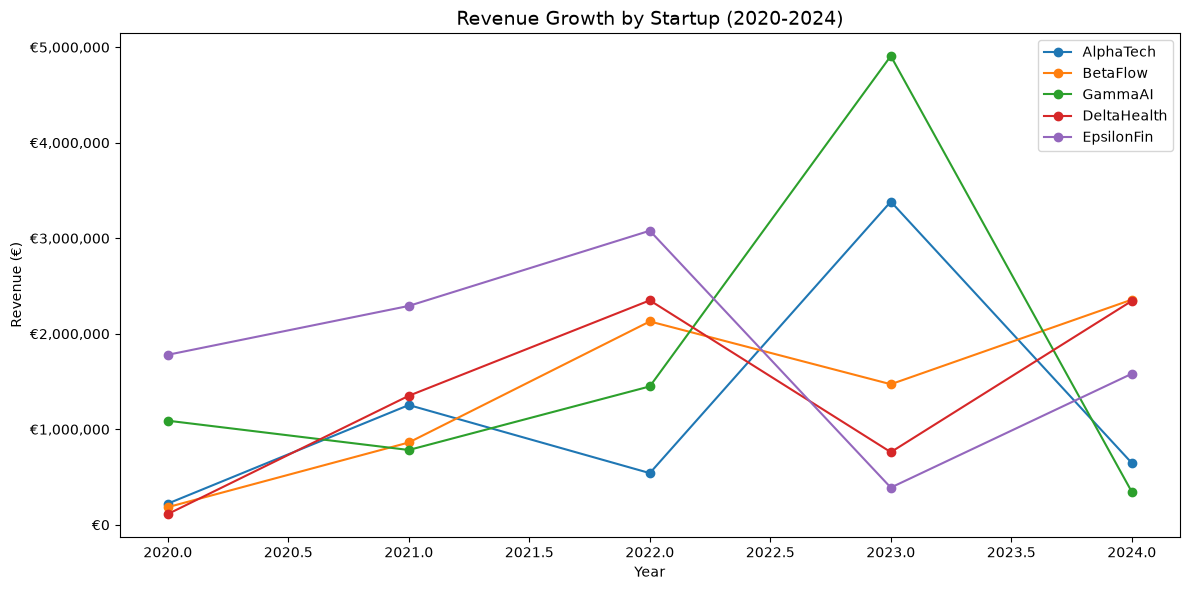

In [24]:
# Revenue Growth by Startup
fig, ax = plt.subplots(figsize=(12, 6))

for startup in startups:
    data_startup = df[df['Startup'] == startup]
    ax.plot(data_startup['Year'], data_startup['Revenue'], marker='o', label=startup)

ax.set_title('Revenue Growth by Startup (2020-2024)', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('Revenue (€)')
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'€{x:,.0f}'))
plt.tight_layout()
plt.show()

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Seed for reproducibility
np.random.seed(42)

# Startups
startups = ['AlphaTech', 'BetaFlow', 'GammaAI', 'DeltaHealth', 'EpsilonFin']

# Years
years = [2020, 2021, 2022, 2023, 2024]

data = []

for startup in startups:
    for year in years:
        revenue = np.random.randint(100000, 2000000) * (1 + np.random.uniform(0.1, 0.5)) ** (year - 2020)
        expenses = revenue * np.random.uniform(1.1, 1.5)
        customers = np.random.randint(50, 500) * (year - 2018)
        cac = np.random.uniform(50, 300)
        ltv = cac * np.random.uniform(2, 5)
        
        data.append({
            'Startup': startup,
            'Year': year,
            'Revenue': round(revenue),
            'Expenses': round(expenses),
            'Customers': customers,
            'CAC': round(cac, 2),
            'LTV': round(ltv, 2)
        })

df = pd.DataFrame(data)
df['Burn_Rate'] = df['Expenses'] - df['Revenue']
df['Gross_Margin'] = ((df['Revenue'] - df['Expenses']) / df['Revenue'] * 100).round(2)
df['LTV_CAC_Ratio'] = (df['LTV'] / df['CAC']).round(2)

print(df.head(10))

     Startup  Year  Revenue  Expenses  Customers     CAC      LTV  Burn_Rate  \
0  AlphaTech  2020   221958    260440        242  199.66   492.78      38482   
1  AlphaTech  2021  1253864   1609584       1266  200.28   825.99     355720   
2  AlphaTech  2022   541065    751431       1852  103.08   262.40     210366   
3  AlphaTech  2023  3383362   4549476       1510  157.99   454.00    1166114   
4  AlphaTech  2024   646967    723740       1422  141.59   476.91      76773   
5   BetaFlow  2020   184654    231369        586  198.10   423.81      46715   
6   BetaFlow  2021   861937   1103452        969  287.22  1406.49     241515   
7   BetaFlow  2022  2129150   2355663       1740  221.06   734.01     226513   
8   BetaFlow  2023  1471665   1639074       1275  147.77   376.31     167409   
9   BetaFlow  2024  2357085   2788847       1854   96.21   472.29     431762   

   Gross_Margin  LTV_CAC_Ratio  
0        -17.34           2.47  
1        -28.37           4.12  
2        -38.88     